# LSTM Crime Rate Forecasting
### CRIMSON — Predictive Analytics Module

This notebook trains a **Long Short-Term Memory (LSTM)** neural network to forecast monthly crime rates across Sri Lanka.

| | |
|---|---|
| **Dataset** | 9,800 crime incidents · 22 districts · 2015–2024 |
| **Model** | Stacked LSTM (32 → 16 units) with Dropout |
| **Target** | Monthly crime count (next 12 months) |
| **Saved to** | `./trained/lstm_model.keras` |

**Used in CRIMSON app:**
- `Officer/Prediction.jsx` — "Crime will increase next month in Colombo"
- `Admin/Dashboard.jsx` — Forecast chart widget

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
import warnings, os, joblib
warnings.filterwarnings("ignore")
print("[OK] All imports successful")

✅ All imports successful


## 📥 1. Load Dataset

Load the raw crime incident CSV and parse dates.

In [ ]:
DATA_PATH = "./data/crime_data.csv"

df = pd.read_csv(DATA_PATH)

if "year" not in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["date"].dt.year

print(f"[OK] Loaded {len(df):,} records  |  Years: {sorted(df['year'].dropna().unique().astype(int).tolist())}")
print(f"Columns: {list(df.columns)}")
df.head()

✅ Loaded 9,800 records  |  Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
📋 Columns: ['incident_id', 'district', 'police_division', 'crime_type', 'date', 'day_of_week', 'is_holiday', 'time_bracket', 'location_type', 'lighting_level', 'victim_gender', 'victim_age_bracket', 'prior_offenses', 'offender_drug_history', 'reported_2015_total', 'solved_2015_total', 'cleared_rate_pct', 'reported_status', 'referral_source', 'year']


,incident_id,district,police_division,crime_type,date,day_of_week,is_holiday,time_bracket,location_type,lighting_level,victim_gender,victim_age_bracket,prior_offenses,offender_drug_history,reported_2015_total,solved_2015_total,cleared_rate_pct,reported_status,referral_source,year
0,2015-COL-001,Colombo,Colombo South,Homicide,2015-01-08,Thursday,Yes,Night,Public Space,Poorly-lit,Male,35-45,0,No,568,540,95,Solved,Police,2015
1,2015-COL-002,Colombo,Nugegoda,House Breaking,2015-04-14,Tuesday,Yes,Night,Residential,Dark,Female,45-60,1,No,9245,3050,33,Under Investigation,Police,2015
2,2015-GAM-001,Gampaha,Kelaniya,Drug Offences (Heroin),2015-02-15,Sunday,No,Morning,Transport Hub,Well-lit,Male,18-24,3,Yes,26145,25000,95,Solved,Police,2015
3,2015-KAN-001,Kandy,Kandy Central,Robbery,2015-08-10,Monday,No,Evening,Commercial,Well-lit,Male,25-35,2,No,3542,2300,65,Solved,Self-Reported,2015
4,2015-KAL-001,Kalutara,Panadura,Grievous Hurt,2015-03-22,Sunday,No,Evening,Public Space,Poorly-lit,Male,25-35,1,No,1410,1290,91,Solved,Hospital,2015


## 🔍 2. Exploratory Data Analysis

Inspect shape, dtypes, missing values, and key distributions.

In [5]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nYear range:", df["year"].min(), "–", df["year"].max())
print("\nDistricts:", df["district"].nunique(), "unique")
print("\nCrime types:", df["crime_type"].nunique(), "unique")
print("\nTime brackets:", df["time_bracket"].unique())

Shape: (9800, 20)

Data types:
 incident_id                         str
district                            str
police_division                     str
crime_type                          str
date                     datetime64[us]
day_of_week                         str
is_holiday                          str
time_bracket                        str
location_type                       str
lighting_level                      str
victim_gender                       str
victim_age_bracket                  str
prior_offenses                    int64
offender_drug_history               str
reported_2015_total               int64
solved_2015_total                 int64
cleared_rate_pct                  int64
reported_status                     str
referral_source                     str
year                              int32
dtype: object

Missing values:
 incident_id              0
district                 0
police_division          0
crime_type               0
date                     0
d

## 📈 3. Monthly Time Series Aggregation

Aggregate daily incidents into monthly counts, apply 3-month rolling smoothing to reduce noise, and visualise the trend.

📊 Monthly points: 114
📈 Min: 18  Max: 150  Mean: 86.0
   year_month  count       date  count_smooth
0     2015-01     92 2015-01-01     85.500000
1     2015-02     79 2015-02-01    100.000000
2     2015-03    129 2015-03-01     98.000000
3     2015-04     86 2015-04-01     97.000000
4     2015-05     76 2015-05-01     75.666667
5     2015-06     65 2015-06-01     61.000000
6     2015-07     42 2015-07-01     62.333333
7     2015-08     80 2015-08-01     64.000000
8     2015-09     70 2015-09-01     85.000000
9     2015-10    105 2015-10-01     91.333333
10    2015-11     99 2015-11-01     93.666667
11    2015-12     77 2015-12-01     87.666667


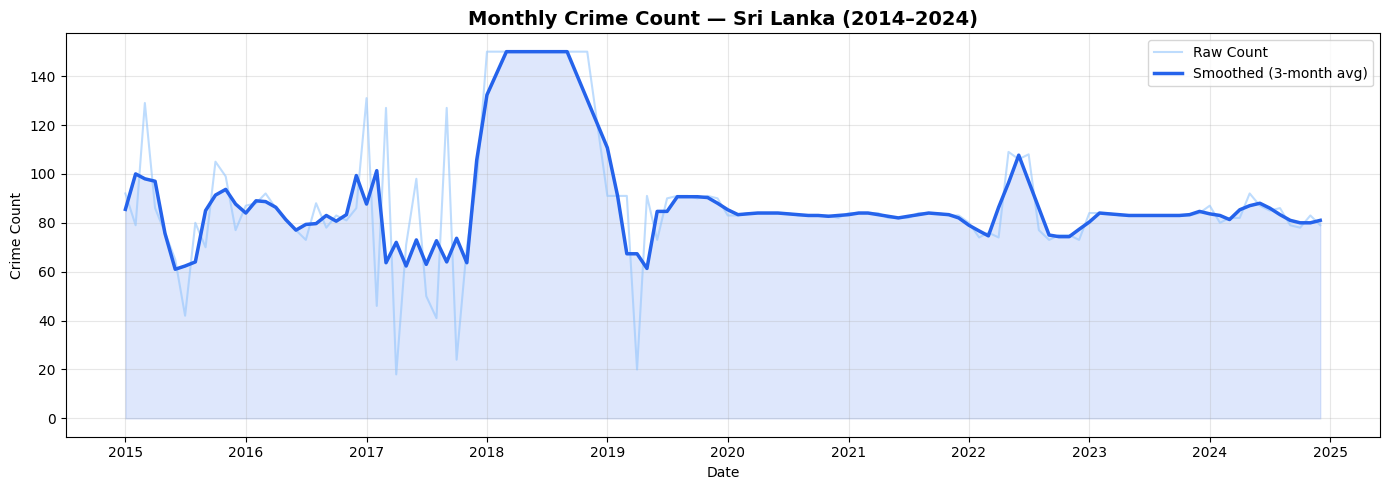

✅ Trend plot saved


In [6]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])
df["year_month"] = df["date"].dt.to_period("M")

monthly = (
    df.groupby("year_month")
      .size()
      .reset_index(name="count")
)
monthly["date"] = monthly["year_month"].dt.to_timestamp()
monthly = monthly.sort_values("date").reset_index(drop=True)

monthly["count_smooth"] = (
    monthly["count"]
    .rolling(window=3, min_periods=1, center=True)
    .mean()
)

print(f"📊 Monthly points: {len(monthly)}")
print(f"📈 Min: {monthly['count'].min()}  Max: {monthly['count'].max()}  Mean: {monthly['count'].mean():.1f}")
print(monthly.head(12))

plt.figure(figsize=(14, 5))
plt.plot(monthly["date"], monthly["count"],
         color="#93c5fd", linewidth=1.5, alpha=0.6, label="Raw Count")
plt.plot(monthly["date"], monthly["count_smooth"],
         color="#2563eb", linewidth=2.5, label="Smoothed (3-month avg)")
plt.fill_between(monthly["date"], monthly["count_smooth"], alpha=0.15, color="#2563eb")
plt.title("Monthly Crime Count — Sri Lanka (2014–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Date"); plt.ylabel("Crime Count")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lstm_monthly_trend.png", dpi=150)
plt.show()
print("✅ Trend plot saved")

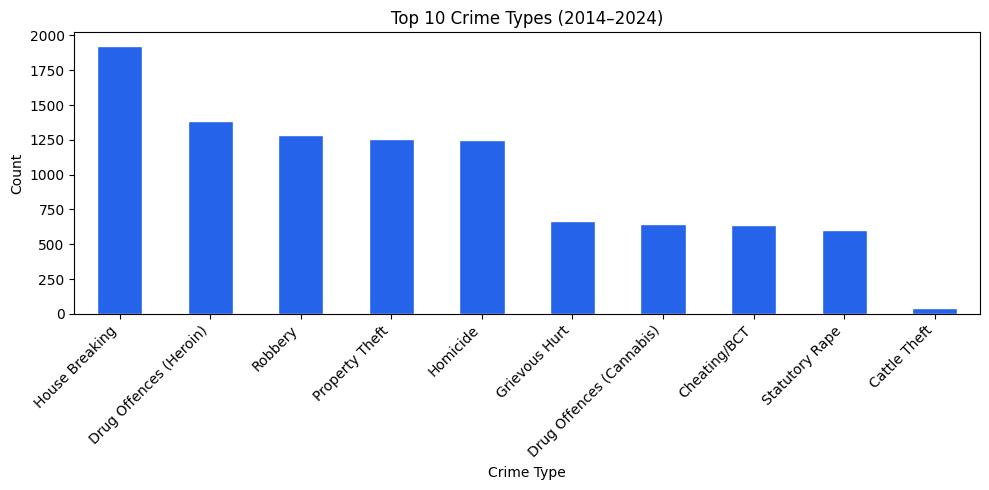


Top Districts by Crime Count:
district
Colombo         751
Gampaha         735
Kandy           723
Jaffna          715
Kalutara        714
Galle           714
Kurunegala      705
Anuradhapura    700
Ratnapura       698
Batticaloa      682
Name: count, dtype: int64


In [7]:
crime_counts = df["crime_type"].value_counts()
plt.figure(figsize=(10, 5))
crime_counts.head(10).plot(kind="bar", color="#2563eb", edgecolor="white")
plt.title("Top 10 Crime Types (2014–2024)")
plt.xlabel("Crime Type"); plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("crime_type_distribution.png", dpi=150)
plt.show()

print("\nTop Districts by Crime Count:")
print(df["district"].value_counts().head(10))

## 🔢 4. Feature Scaling & Sequence Building

- **MinMaxScaler** normalises the smoothed count to [0, 1]  
- **LOOKBACK = 6** — the model sees the last 6 months to predict the next  
- **80/20 train/test split** on the resulting sequences

In [8]:
LOOKBACK = 6

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(monthly[["count_smooth"]])

def build_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = build_sequences(scaled, LOOKBACK)
X    = X.reshape(X.shape[0], X.shape[1], 1)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"✅ Train samples: {len(X_train)}")
print(f"✅ Test  samples: {len(X_test)}")

✅ Train samples: 86
✅ Test  samples: 22


## 🧠 5. Build & Train LSTM Model

**Architecture:** `LSTM(32) → Dropout(0.1) → LSTM(16) → Dropout(0.1) → Dense(8, relu) → Dense(1)`

- **Optimiser:** Adam (lr=0.001)  
- **Loss:** MSE  
- **Callbacks:** EarlyStopping (patience=30) + ReduceLROnPlateau (patience=15)  
- **Epochs:** up to 300 (early stops when validation loss plateaus)

In [9]:
model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.1),
    LSTM(16),
    Dropout(0.1),
    Dense(8, activation="relu"),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=15, min_lr=1e-7)
]

history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=4,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 6, 32)               │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,633 (29.82 KB)

 Trainable params: 7,633 (29.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - loss: 0.1016 - mae: 0.2428 - val_loss: 0.0254 - val_mae: 0.1094 - learning_rate: 0.0010
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0497 - mae: 0.1414 - val_loss: 0.0210 - val_mae: 0.1289 - learning_rate: 0.0010
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0449 - mae: 0.1352 - val_loss: 0.0176 - val_mae: 0.1088 - learning_rate: 0.0010
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0460 - mae: 0.1387 - val_loss: 0.0186 - val_mae: 0.1174 - learning_rate: 0.0010
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0467 - mae: 0.1273 - val_loss: 0.0171 - val_mae: 0.1074 - learning_rate: 0.0010
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0427 - mae: 0.1279 - val_loss: 0.0184 - val_mae: 0.1170 - learning_rate: 0.0010
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0427 - mae: 0.1428 - val_loss: 0.0187 - val_mae: 0.1187 - learning_rate: 0.0010
Epoc

## 📉 6. Model Evaluation

Metrics computed on the **held-out test set** (last 20% of months):

| Metric | Meaning |
|---|---|
| **MAE** | Mean Absolute Error (raw counts) |
| **RMSE** | Root Mean Squared Error |
| **R²** | Coefficient of determination |
| **MAPE** | Mean Absolute Percentage Error |
| **Accuracy** | `100 - MAPE` |

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
  MAE:      1.1609
  RMSE:     1.6176
  R²:       0.3322
  MAPE:     1.38%
  Accuracy: 98.62%


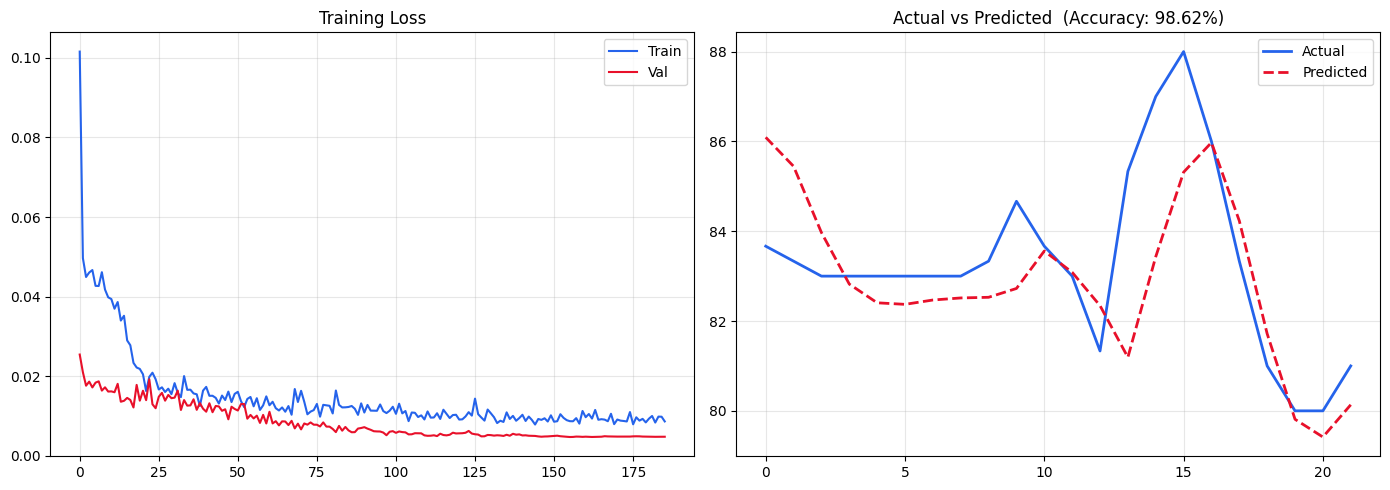

In [10]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1))) * 100
acc  = round(max(0, 100 - mape), 2)

print("=" * 40)
print(f"  MAE:      {mae:.4f}")
print(f"  RMSE:     {rmse:.4f}")
print(f"  R²:       {r2:.4f}")
print(f"  MAPE:     {mape:.2f}%")
print(f"  Accuracy: {acc:.2f}%")
print("=" * 40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["loss"],     label="Train", color="#2563eb")
axes[0].plot(history.history["val_loss"], label="Val",   color="#e8102a")
axes[0].set_title("Training Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(y_true, label="Actual",    color="#2563eb", linewidth=2)
axes[1].plot(y_pred, label="Predicted", color="#e8102a", linewidth=2, linestyle="--")
axes[1].set_title(f"Actual vs Predicted  (Accuracy: {acc}%)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lstm_evaluation.png", dpi=150)
plt.show()

## 🔮 7. Future Crime Forecast — Next 12 Months

Auto-regressively generate 12 monthly predictions beyond the last known data point.  
Each predicted step is fed back as input for the next step.

      date  forecast
2025-01-01 81.534889
2025-02-01 82.458351
2025-03-01 83.125008
2025-04-01 83.448059
2025-05-01 83.421196
2025-06-01 83.122383
2025-07-01 82.689507
2025-08-01 82.250854
2025-09-01 81.925331
2025-10-01 81.772354
2025-11-01 81.795967
2025-12-01 81.954094


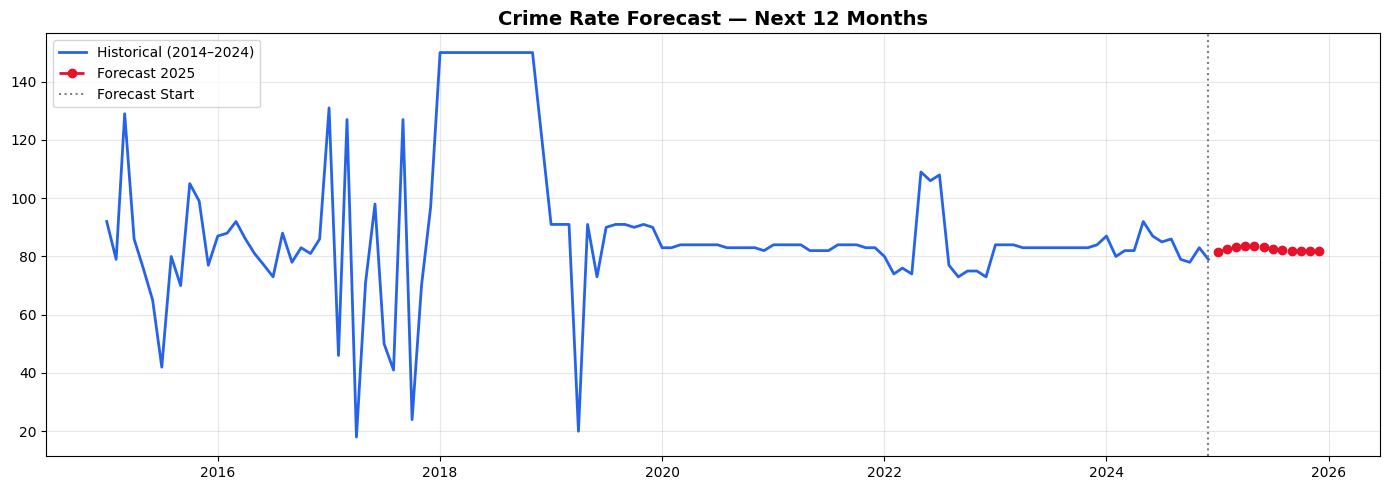

In [11]:
def forecast_future(steps=12):
    seed  = scaled[-LOOKBACK:].reshape(1, LOOKBACK, 1)
    preds = []
    for _ in range(steps):
        p    = model.predict(seed, verbose=0)[0][0]
        preds.append(p)
        seed = np.append(seed[:, 1:, :], [[[p]]], axis=1)
    vals  = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
    dates = pd.date_range(
        start=monthly["date"].max() + pd.DateOffset(months=1),
        periods=steps, freq="MS")
    return pd.DataFrame({"date": dates, "forecast": vals})

forecast_df = forecast_future(12)
print(forecast_df.to_string(index=False))

plt.figure(figsize=(14, 5))
plt.plot(monthly["date"], monthly["count"],
         label="Historical (2014–2024)", color="#2563eb", linewidth=2)
plt.plot(forecast_df["date"], forecast_df["forecast"],
         label="Forecast 2025", color="#e8102a",
         linewidth=2, linestyle="--", marker="o")
plt.axvline(monthly["date"].max(), color="grey", linestyle=":", label="Forecast Start")
plt.title("Crime Rate Forecast — Next 12 Months", fontsize=14, fontweight="bold")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lstm_forecast.png", dpi=150)
plt.show()

## 💾 8. Save Artifacts & Verify

Save the trained model and preprocessors to `./trained/` so `main.py` can load them at startup.

| File | Used by |
|---|---|
| `lstm_model.keras` | `load_model()` in main.py |
| `lstm_scaler.pkl` | `inverse_transform()` predictions |
| `monthly_data.pkl` | seed for auto-regressive forecast |

In [12]:
os.makedirs("./trained", exist_ok=True)
model.save("./trained/lstm_model.keras")
joblib.dump(scaler,  "./trained/lstm_scaler.pkl")
joblib.dump(monthly, "./trained/monthly_data.pkl")

print("✅ LSTM model saved → ./trained/lstm_model.keras")
print(f"🎯 Final Accuracy: {acc}%")

✅ LSTM model saved → ./trained/lstm_model.keras
🎯 Final Accuracy: 98.62%


In [ ]:
# ── Verify saved artifacts ────────────────────────────────
from keras.models import load_model as keras_load_model

loaded_model  = keras_load_model("./trained/lstm_model.keras")
loaded_scaler = joblib.load("./trained/lstm_scaler.pkl")
loaded_monthly = joblib.load("./trained/monthly_data.pkl")

print("[OK] lstm_model.keras   loaded  | params:", loaded_model.count_params())
print("[OK] lstm_scaler.pkl    loaded  | feature range:", loaded_scaler.feature_range)
print("[OK] monthly_data.pkl   loaded  | rows:", len(loaded_monthly))
print()
print("Monthly data columns:", loaded_monthly.columns.tolist())
print("Date range:", loaded_monthly["date"].min(), "→", loaded_monthly["date"].max())
print()
print("=" * 45)
print(f"  FINAL ACCURACY : {acc:.2f}%")
print(f"  MAE            : {mae:.4f}")
print(f"  RMSE           : {rmse:.4f}")
print(f"  R²             : {r2:.4f}")
print("=" * 45)
print("[DONE] LSTM model successfully trained and saved!")

NameError: name 'monthly_data' is not defined